In [181]:
!pip -q install yfinance

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt


In [182]:
tickers = [
    "AAPL", "MSFT", "AMZN", "GOOGL", "META", "NVDA",
    "JPM", "BAC", "GS", "MS",
    "XOM", "CVX",
    "JNJ", "PFE", "MRK", "ABBV",
    "PG", "KO", "PEP", "WMT", "COST",
    "HD", "LOW", "MCD", "SBUX",
    "CRM", "ORCL", "ADBE", "CSCO", "AMD"
]

start_date = "2016-01-01"
end_date = "2024-12-31"

In [183]:
raw = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    auto_adjust=True,
    progress=False
)

print(raw.shape)
raw.head()

(2263, 150)


Price           Close                                                    \
Ticker           AAPL       ABBV       ADBE   AMD       AMZN        BAC   
Date                                                                      
2016-01-04  23.730940  37.707527  91.970001  2.77  31.849501  13.122289   
2016-01-05  23.136259  37.550453  92.339996  2.75  31.689501  13.122289   
2016-01-06  22.683498  37.556995  91.019997  2.51  31.632500  12.842752   
2016-01-07  21.726152  37.445721  89.110001  2.28  30.396999  12.379519   
2016-01-08  21.841026  36.424660  87.849998  2.14  30.352501  12.139916   

Price                                                    ...    Volume  \
Ticker            COST        CRM       CSCO        CVX  ...        MS   
Date                                                     ...             
2016-01-04  134.243973  75.789146  19.448946  57.362316  ...  15749200   
2016-01-05  134.572159  76.125069  19.360582  57.852959  ...   9850500   
2016-01-06  133.326828  75.374184  19.154375  55.567520  ...  13057400   
2016-01-07  130.272400  73.408073  18.712523  53.598408  ...  18138200   
2016-01-08  127.992050  72.350922  18.248585  53.023827  ...  15295600   

Price                                                                   \
Ticker          MSFT       NVDA      ORCL      PEP       PFE        PG   
Date                                                                     
2016-01-04  53778000  358076000  18784400  6689000  39322421  11529800   
2016-01-05  34079700  490272000  25340700  4893800  28777994   8133700   
2016-01-06  39518900  449344000  18165700  5483400  27242316   9551000   
2016-01-07  56564900  645304000  22591400  5440000  39223134  11973900   
2016-01-08  48754000  398472000  21962200  4853500  34840286   9676400   

Price                                     
Ticker          SBUX       WMT       XOM  
Date                                      
2016-01-04  13521500  35967600  20400100  
2016-01-05   9617800  39978000  11993500  
2016-01-06   8266300  49693800  18826900  
2016-01-07  11140900  79290000  21263800  
2016-01-08  10427000  53303700  19033600  

[5 rows x 150 columns]

In [184]:
raw.columns

MultiIndex([( 'Close', 'AAPL'),
            ( 'Close', 'ABBV'),
            ( 'Close', 'ADBE'),
            ( 'Close',  'AMD'),
            ( 'Close', 'AMZN'),
            ( 'Close',  'BAC'),
            ( 'Close', 'COST'),
            ( 'Close',  'CRM'),
            ( 'Close', 'CSCO'),
            ( 'Close',  'CVX'),
            ...
            ('Volume',   'MS'),
            ('Volume', 'MSFT'),
            ('Volume', 'NVDA'),
            ('Volume', 'ORCL'),
            ('Volume',  'PEP'),
            ('Volume',  'PFE'),
            ('Volume',   'PG'),
            ('Volume', 'SBUX'),
            ('Volume',  'WMT'),
            ('Volume',  'XOM')],
           names=['Price', 'Ticker'], length=150)

In [185]:
# Selezioniamo solo le variabili utili
panel = raw[["Close", "Volume"]].copy()

# Trasformiamo da wide a long
panel = panel.stack(level=1).reset_index()

# Rinominiamo colonne
panel.columns = ["Date", "Ticker", "Close", "Volume"]

# Ordiniamo
panel = panel.sort_values(["Ticker", "Date"]).reset_index(drop=True)

panel.head(10)

,Date,Ticker,Close,Volume
0,2016-01-04,AAPL,23.730940,270597600
1,2016-01-05,AAPL,23.136259,223164000
2,2016-01-06,AAPL,22.683498,273829600
3,2016-01-07,AAPL,21.726152,324377600
4,2016-01-08,AAPL,21.841026,283192000
5,2016-01-11,AAPL,22.194685,198957600
6,2016-01-12,AAPL,22.516813,196616800
7,2016-01-13,AAPL,21.937889,249758400
8,2016-01-14,AAPL,22.417696,252680400
9,2016-01-15,AAPL,21.879320,319335600


In [186]:
panel.isna().sum()

,0
Date,0
Ticker,0
Close,0
Volume,0


In [187]:
panel["Return_1d"] = panel.groupby("Ticker")["Close"].pct_change()

# target: rendimento del giorno successivo
panel["Target"] = panel.groupby("Ticker")["Return_1d"].shift(-1)

panel.head(10)

,Date,Ticker,Close,Volume,Return_1d,Target
0,2016-01-04,AAPL,23.730940,270597600,NaN,-0.025059
1,2016-01-05,AAPL,23.136259,223164000,-0.025059,-0.019569
2,2016-01-06,AAPL,22.683498,273829600,-0.019569,-0.042205
3,2016-01-07,AAPL,21.726152,324377600,-0.042205,0.005287
4,2016-01-08,AAPL,21.841026,283192000,0.005287,0.016192
5,2016-01-11,AAPL,22.194685,198957600,0.016192,0.014514
6,2016-01-12,AAPL,22.516813,196616800,0.014514,-0.025711
7,2016-01-13,AAPL,21.937889,249758400,-0.025711,0.021871
8,2016-01-14,AAPL,22.417696,252680400,0.021871,-0.024016
9,2016-01-15,AAPL,21.879320,319335600,-0.024016,-0.004839


In [188]:
# Lagged returns
panel["Ret_lag_1"] = panel.groupby("Ticker")["Return_1d"].shift(1)
panel["Ret_lag_5"] = panel.groupby("Ticker")["Close"].pct_change(5)
panel["Ret_lag_20"] = panel.groupby("Ticker")["Close"].pct_change(20)

# Rolling volatility
panel["Volatility_20"] = (
    panel.groupby("Ticker")["Return_1d"]
    .rolling(20)
    .std()
    .reset_index(level=0, drop=True)
)

# Moving averages
panel["MA_5"] = (
    panel.groupby("Ticker")["Close"]
    .rolling(5)
    .mean()
    .reset_index(level=0, drop=True)
)

panel["MA_20"] = (
    panel.groupby("Ticker")["Close"]
    .rolling(20)
    .mean()
    .reset_index(level=0, drop=True)
)

# Distance from moving averages
panel["Dist_MA_5"] = panel["Close"] / panel["MA_5"] - 1
panel["Dist_MA_20"] = panel["Close"] / panel["MA_20"] - 1

# Volume change
panel["Volume_Change_1"] = panel.groupby("Ticker")["Volume"].pct_change(1)
panel["Volume_Change_5"] = panel.groupby("Ticker")["Volume"].pct_change(5)

panel.head(10)

,Date,Ticker,Close,Volume,Return_1d,Target,Ret_lag_1,Ret_lag_5,Ret_lag_20,Volatility_20,MA_5,MA_20,Dist_MA_5,Dist_MA_20,Volume_Change_1,Volume_Change_5
0,2016-01-04,AAPL,23.730940,270597600,NaN,-0.025059,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2016-01-05,AAPL,23.136259,223164000,-0.025059,-0.019569,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.175292,NaN
2,2016-01-06,AAPL,22.683498,273829600,-0.019569,-0.042205,-0.025059,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.227033,NaN
3,2016-01-07,AAPL,21.726152,324377600,-0.042205,0.005287,-0.019569,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.184597,NaN
4,2016-01-08,AAPL,21.841026,283192000,0.005287,0.016192,-0.042205,NaN,NaN,NaN,22.623575,NaN,-0.034590,NaN,-0.126968,NaN
5,2016-01-11,AAPL,22.194685,198957600,0.016192,0.014514,0.005287,-0.064736,NaN,NaN,22.316324,NaN,-0.005451,NaN,-0.297446,-0.264747
6,2016-01-12,AAPL,22.516813,196616800,0.014514,-0.025711,0.016192,-0.026774,NaN,NaN,22.192435,NaN,0.014617,NaN,-0.011765,-0.118958
7,2016-01-13,AAPL,21.937889,249758400,-0.025711,0.021871,0.014514,-0.032870,NaN,NaN,22.043313,NaN,-0.004783,NaN,0.270280,-0.087906
8,2016-01-14,AAPL,22.417696,252680400,0.021871,-0.024016,-0.025711,0.031830,NaN,NaN,22.181622,NaN,0.010643,NaN,0.011699,-0.221030
9,2016-01-15,AAPL,21.879320,319335600,-0.024016,-0.004839,0.021871,0.001753,NaN,NaN,22.189281,NaN,-0.013969,NaN,0.263793,0.127629


In [189]:
features = [
    "Ret_lag_1",
    "Ret_lag_5",
    "Ret_lag_20",
    "Volatility_20",
    "Dist_MA_5",
    "Dist_MA_20",
    "Volume_Change_1",
    "Volume_Change_5"
]

model_data = panel[["Date", "Ticker", "Target"] + features].copy()
model_data = model_data.replace([np.inf, -np.inf], np.nan)
model_data = model_data.dropna().reset_index(drop=True)

print(model_data.shape)
model_data.head()

(67260, 11)


,Date,Ticker,Target,Ret_lag_1,Ret_lag_5,Ret_lag_20,Volatility_20,Dist_MA_5,Dist_MA_20,Volume_Change_1,Volume_Change_5
0,2016-02-02,AAPL,0.019792,-0.009349,-0.055105,-0.103179,0.026989,-0.007062,-0.033803,-0.087591,-0.502415
1,2016-02-03,AAPL,0.008035,-0.020222,0.031363,-0.061922,0.027105,0.006392,-0.011465,0.230400,-0.655362
2,2016-02-04,AAPL,-0.026708,0.019792,0.032248,-0.035510,0.026911,0.008089,-0.001691,0.011039,-0.165361
3,2016-02-05,AAPL,0.010530,0.008035,-0.028866,-0.019905,0.025879,-0.013079,-0.027395,-0.001153,-0.279407
4,2016-02-08,AAPL,-0.000210,-0.026708,-0.009379,-0.014794,0.025969,-0.000800,-0.016428,0.163800,0.319413


In [190]:
print("Date min:", model_data["Date"].min())
print("Date max:", model_data["Date"].max())
print("Number of tickers:", model_data["Ticker"].nunique())
print("Tickers:", sorted(model_data["Ticker"].unique()))

Date min: 2016-02-02 00:00:00
Date max: 2024-12-27 00:00:00
Number of tickers: 30
Tickers: ['AAPL', 'ABBV', 'ADBE', 'AMD', 'AMZN', 'BAC', 'COST', 'CRM', 'CSCO', 'CVX', 'GOOGL', 'GS', 'HD', 'JNJ', 'JPM', 'KO', 'LOW', 'MCD', 'META', 'MRK', 'MS', 'MSFT', 'NVDA', 'ORCL', 'PEP', 'PFE', 'PG', 'SBUX', 'WMT', 'XOM']


In [191]:
model_data[["Target"] + features].describe().T

,count,mean,std,min,25%,50%,75%,max
Target,67260.0,0.000882,0.018762,-0.263901,-0.007007,0.000803,0.008889,0.522901
Ret_lag_1,67260.0,0.000878,0.018772,-0.263901,-0.007007,0.000805,0.008893,0.522901
Ret_lag_5,67260.0,0.004344,0.040179,-0.344226,-0.014991,0.004420,0.023534,0.477778
Ret_lag_20,67260.0,0.017477,0.079547,-0.502890,-0.024904,0.016481,0.057619,0.692706
Volatility_20,67260.0,0.015970,0.010080,0.002383,0.009688,0.013297,0.018913,0.126749
Dist_MA_5,67260.0,0.001472,0.019804,-0.224910,-0.007362,0.001805,0.010932,0.358067
Dist_MA_20,67260.0,0.007216,0.043702,-0.386824,-0.014724,0.008448,0.029950,0.414141
Volume_Change_1,67260.0,0.062425,0.432298,-0.896900,-0.182277,-0.014598,0.204839,16.390897
Volume_Change_5,67260.0,0.113588,0.628429,-0.926622,-0.236505,-0.012374,0.292612,19.175057


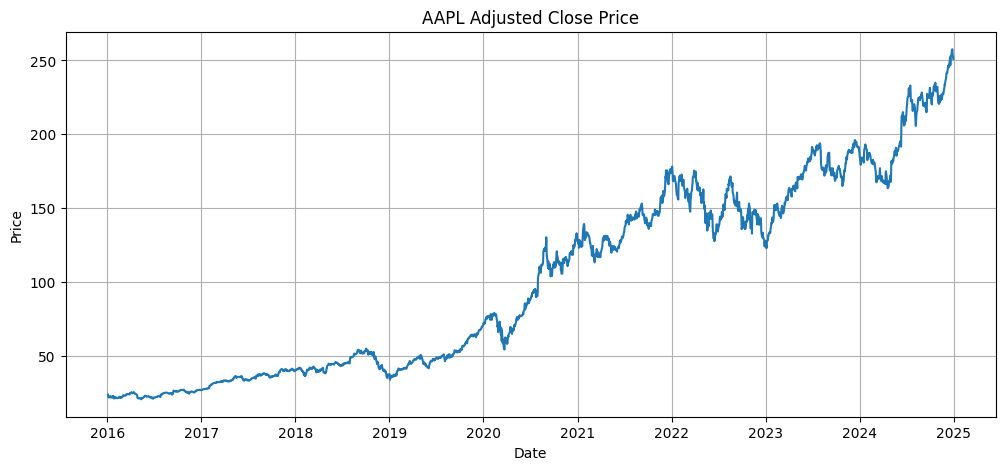

In [192]:
example_ticker = "AAPL"

tmp = panel[panel["Ticker"] == example_ticker].copy()

plt.figure(figsize=(12, 5))
plt.plot(tmp["Date"], tmp["Close"])
plt.title(f"{example_ticker} Adjusted Close Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.show()

In [193]:
train_data = model_data[model_data["Date"] < "2023-01-01"]
test_data  = model_data[model_data["Date"] >= "2023-01-01"]

print("Train size:", train_data.shape)
print("Test size:", test_data.shape)

Train size: (52260, 11)
Test size: (15000, 11)


In [194]:
X_train = train_data[features]
y_train = train_data["Target"]

X_test = test_data[features]
y_test = test_data["Target"]

In [195]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

mse_lr = mean_squared_error(y_test, pred_lr)

print("Linear Regression MSE:", mse_lr)

Linear Regression MSE: 0.00028340073008846685


In [196]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

mse_rf = mean_squared_error(y_test, pred_rf)

print("Random Forest MSE:", mse_rf)

Random Forest MSE: 0.0002811266025674718


In [197]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MSE": [mse_lr, mse_rf]
})

results

,Model,MSE
0,Linear Regression,0.000283
1,Random Forest,0.000281


In [198]:
importances = pd.Series(
    rf.feature_importances_,
    index=features
).sort_values(ascending=False)

importances

,0
Ret_lag_1,0.256973
Dist_MA_5,0.224462
Dist_MA_20,0.127046
Volume_Change_5,0.104193
Ret_lag_20,0.079350
Volume_Change_1,0.071733
Volatility_20,0.070835
Ret_lag_5,0.065409


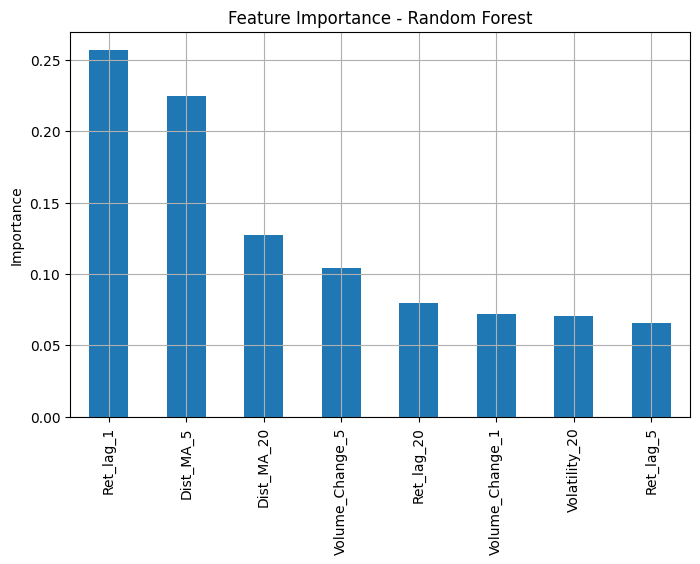

In [199]:
plt.figure(figsize=(8,5))
importances.plot(kind="bar")
plt.title("Feature Importance - Random Forest")
plt.ylabel("Importance")
plt.grid(True)
plt.show()

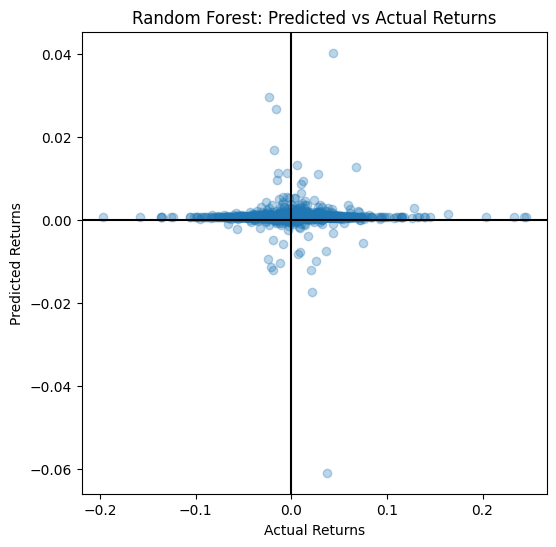

In [200]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, pred_rf, alpha=0.3)

plt.xlabel("Actual Returns")
plt.ylabel("Predicted Returns")
plt.title("Random Forest: Predicted vs Actual Returns")

plt.axhline(0, color="black")
plt.axvline(0, color="black")

plt.show()

In [201]:
test_results = test_data.copy()

test_results["Pred_LR"] = pred_lr
test_results["Pred_RF"] = pred_rf

test_results.head()

,Date,Ticker,Target,Ret_lag_1,Ret_lag_5,Ret_lag_20,Volatility_20,Dist_MA_5,Dist_MA_20,Volume_Change_1,Volume_Change_5,Pred_LR,Pred_RF
1742,2023-01-03,AAPL,0.010314,0.002469,-0.051494,-0.153846,0.019779,-0.023928,-0.081839,0.455425,0.756917,0.002907,0.001013
1743,2023-01-04,AAPL,-0.010605,-0.037405,-0.028224,-0.138239,0.020205,-0.008179,-0.065416,-0.205177,0.291355,-0.001853,0.000588
1744,2023-01-05,AAPL,0.036794,0.010314,-0.008093,-0.125184,0.019772,-0.017123,-0.069168,-0.091466,-0.052385,0.003868,0.000962
1745,2023-01-06,AAPL,0.004089,-0.010605,0.000077,-0.080318,0.021907,0.019025,-0.030835,0.083890,0.159186,-0.001712,0.000743
1746,2023-01-09,AAPL,0.004456,0.036794,0.001693,-0.087627,0.021669,0.022838,-0.022303,-0.193310,-0.081047,0.001879,0.000743


In [202]:
test_results["Rank_RF"] = test_results.groupby("Date")["Pred_RF"].rank()

In [203]:
test_results["Rank_Pct"] = (
    test_results.groupby("Date")["Pred_RF"]
    .rank(pct=True)
)

In [204]:
test_results["Position"] = 0

# Long-only: investe nel top 30% dei titoli previsti migliori
test_results.loc[test_results["Rank_Pct"] >= 0.7, "Position"] = 1

In [205]:
test_results["Weighted_Return"] = test_results["Position"] * test_results["Target"]

In [206]:
daily_strategy = (
    test_results
    .groupby("Date")["Weighted_Return"]
    .sum()
)

n_positions = (
    test_results
    .groupby("Date")["Position"]
    .sum()
)

daily_strategy = daily_strategy / n_positions
daily_strategy = daily_strategy.replace([np.inf, -np.inf], 0).fillna(0)

In [207]:
cumulative_returns = (1 + daily_strategy).cumprod()

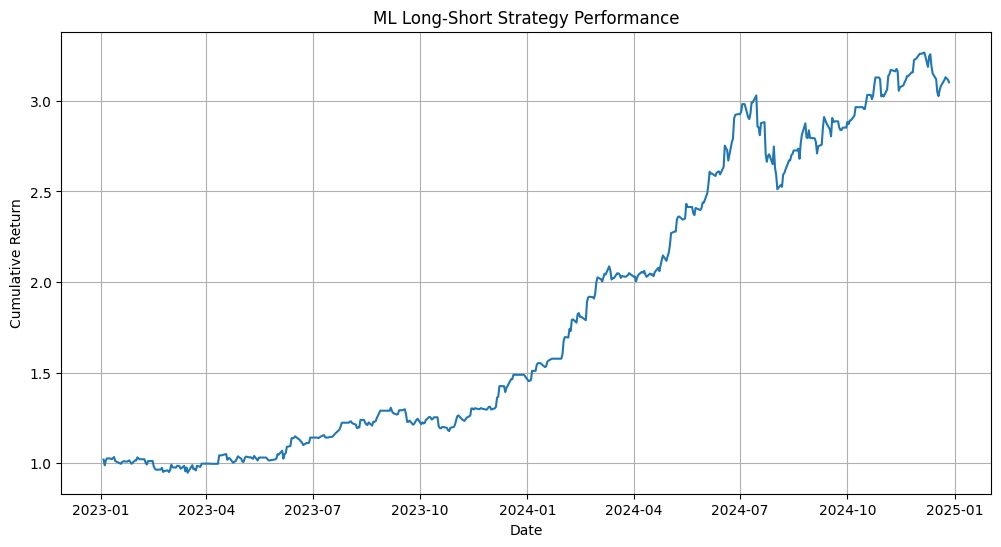

In [208]:
plt.figure(figsize=(12,6))

plt.plot(cumulative_returns)

plt.title("ML Long-Short Strategy Performance")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")

plt.grid(True)
plt.show()

In [209]:
mean_return = daily_strategy.mean()
std_return = daily_strategy.std()

sharpe = np.sqrt(252) * mean_return / std_return

print("Annualized Sharpe Ratio:", sharpe)

Annualized Sharpe Ratio: 2.607807403057501


In [210]:
benchmark_returns = (
    test_results
    .groupby("Date")["Target"]
    .mean()
)

In [211]:
benchmark_cum = (1 + benchmark_returns).cumprod()

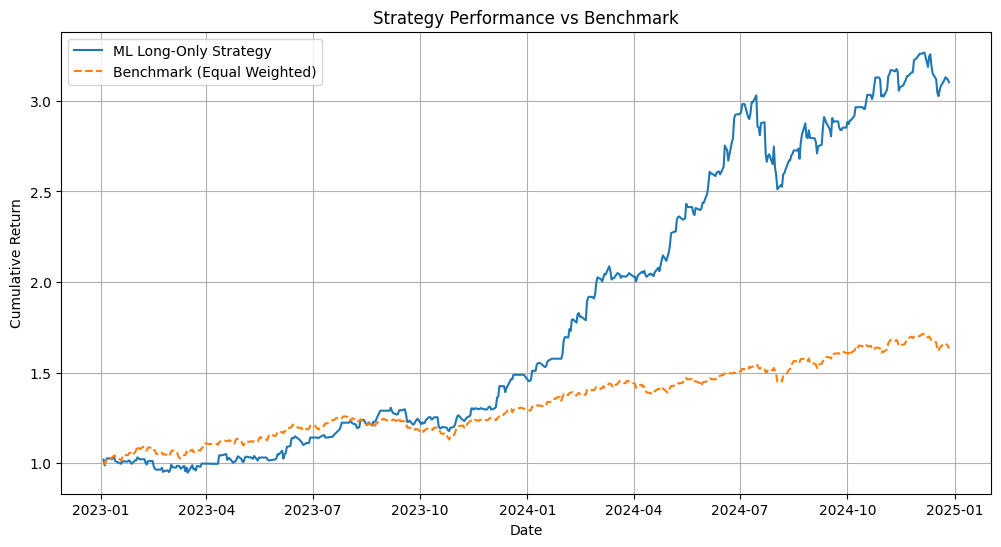

In [212]:
plt.figure(figsize=(12,6))

plt.plot(cumulative_returns, label="ML Long-Only Strategy")
plt.plot(benchmark_cum, label="Benchmark (Equal Weighted)", linestyle="--")

plt.title("Strategy Performance vs Benchmark")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")

plt.legend()
plt.grid(True)

plt.show()

In [213]:
mean_benchmark = benchmark_returns.mean()
std_benchmark = benchmark_returns.std()

sharpe_benchmark = np.sqrt(252) * mean_benchmark / std_benchmark

print("Sharpe Strategy:", sharpe)
print("Sharpe Benchmark:", sharpe_benchmark)

Sharpe Strategy: 2.607807403057501
Sharpe Benchmark: 2.1164239211023217


In [214]:
spy = yf.download("SPY", start="2023-01-01", end="2024-12-31", auto_adjust=True)

spy["Return"] = spy["Close"].pct_change()
spy_returns = spy["Return"].dropna()

[*********************100%***********************]  1 of 1 completed


In [215]:
spy_cum = (1 + spy_returns).cumprod()

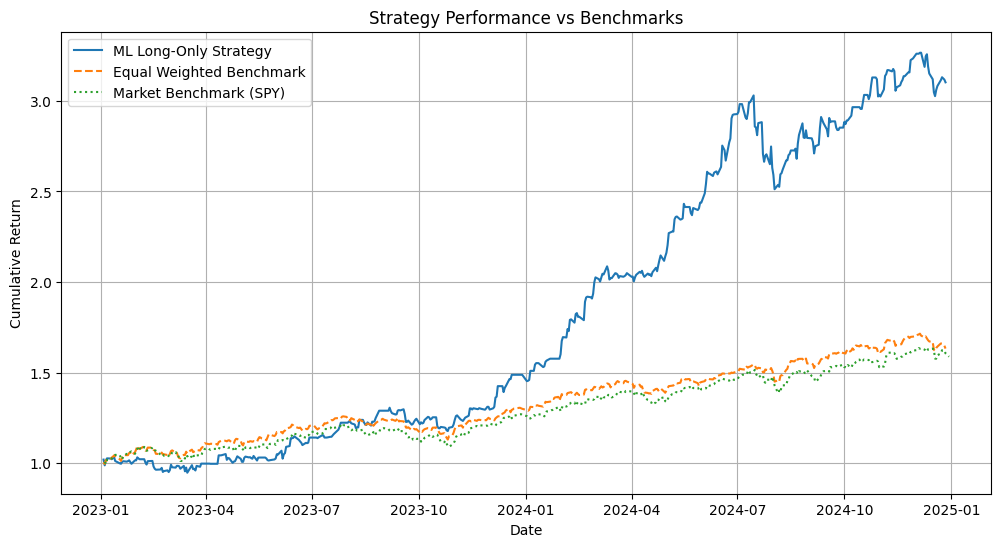

In [216]:
plt.figure(figsize=(12,6))

plt.plot(cumulative_returns, label="ML Long-Only Strategy")
plt.plot(benchmark_cum, label="Equal Weighted Benchmark", linestyle="--")
plt.plot(spy_cum, label="Market Benchmark (SPY)", linestyle=":")

plt.title("Strategy Performance vs Benchmarks")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
#Comparing Performances

In [217]:
performance_df = pd.DataFrame({
    "Strategy": daily_strategy,
    "EqualWeighted": benchmark_returns.reindex(daily_strategy.index),
    "SPY": spy_returns.reindex(daily_strategy.index)
}).dropna()

In [218]:
def performance_metrics(r):

    ann_factor = 252

    cumulative_return = (1 + r).prod() - 1
    cagr = (1 + cumulative_return) ** (ann_factor / len(r)) - 1
    volatility = r.std() * np.sqrt(ann_factor)
    sharpe = (r.mean() / r.std()) * np.sqrt(ann_factor)

    cumulative = (1 + r).cumprod()
    drawdown = cumulative / cumulative.cummax() - 1
    max_dd = drawdown.min()

    calmar = cagr / abs(max_dd) if max_dd != 0 else np.nan

    return pd.Series({
        "CAGR": cagr,
        "CumReturn": cumulative_return,
        "AnnVol": volatility,
        "Sharpe": sharpe,
        "MaxDrawdown": max_dd,
        "Calmar": calmar
    })

In [219]:
performance_table = performance_df.apply(performance_metrics)

performance_table = performance_table.T
performance_table

,CAGR,CumReturn,AnnVol,Sharpe,MaxDrawdown,Calmar
Strategy,0.753401,2.040350,0.228939,2.569662,-0.170898,4.408480
EqualWeighted,0.277133,0.623171,0.120285,2.094649,-0.101850,2.720992
SPY,0.270507,0.606538,0.128099,1.933834,-0.099743,2.712031


In [220]:
performance_table.round(3)

,CAGR,CumReturn,AnnVol,Sharpe,MaxDrawdown,Calmar
Strategy,0.753,2.040,0.229,2.570,-0.171,4.408
EqualWeighted,0.277,0.623,0.120,2.095,-0.102,2.721
SPY,0.271,0.607,0.128,1.934,-0.100,2.712


In [222]:
ic_series = (
    test_results
    .groupby("Date")
    .apply(lambda x: x["Pred_RF"].corr(x["Target"]))
)

ic_series = ic_series.dropna()

print("Mean Information Coefficient:", ic_series.mean())
print("IC Std:", ic_series.std())

Mean Information Coefficient: 0.037154552994958186
IC Std: 0.2665423399767255


In [223]:
icir = ic_series.mean() / ic_series.std()

print("Information Ratio of IC:", icir)

Information Ratio of IC: 0.13939456297338174


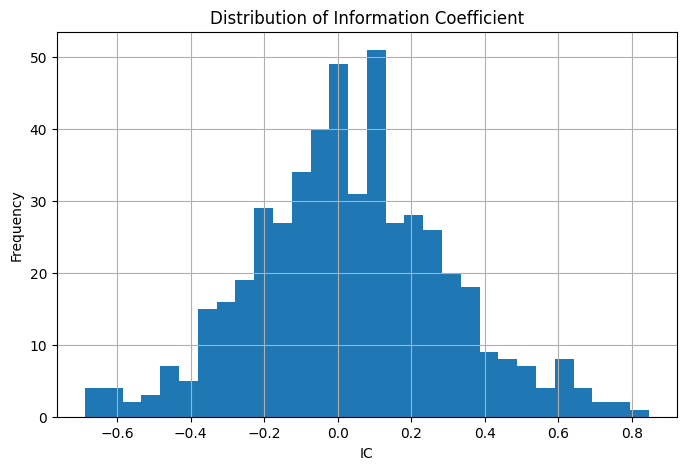

In [224]:
plt.figure(figsize=(8,5))

plt.hist(ic_series, bins=30)

plt.title("Distribution of Information Coefficient")
plt.xlabel("IC")
plt.ylabel("Frequency")

plt.grid(True)
plt.show()

In [225]:
#Ortogonalità

import statsmodels.api as sm

market = spy_returns.reindex(daily_strategy.index).fillna(0)
strategy = daily_strategy

X = sm.add_constant(market)

model = sm.OLS(strategy, X).fit()

print(model.summary())



                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.7232
Date:                Mon, 09 Mar 2026   Prob (F-statistic):              0.396
Time:                        14:46:50   Log-Likelihood:                 1410.6
No. Observations:                 500   AIC:                            -2817.
Df Residuals:                     498   BIC:                            -2809.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0023      0.001      3.543      0.0

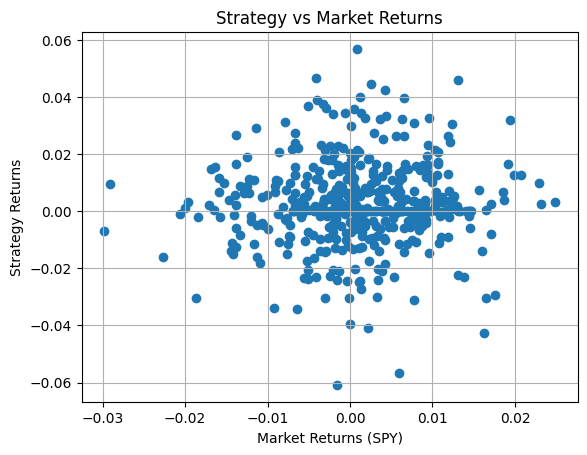

In [227]:
plt.scatter(market, strategy)

plt.xlabel("Market Returns (SPY)")
plt.ylabel("Strategy Returns")

plt.title("Strategy vs Market Returns")

plt.grid(True)
plt.show()



In [228]:
strategy_market_corr = daily_strategy.corr(market)

print("Correlation strategy vs market:", strategy_market_corr)

Correlation strategy vs market: 0.038079321633421495


In [229]:
#CAPM

import pandas as pd
import statsmodels.api as sm

capm_df = pd.DataFrame({
    "strategy": daily_strategy,
    "market": spy_returns
}).dropna()



In [230]:
X = sm.add_constant(capm_df["market"])   # aggiunge alpha
y = capm_df["strategy"]

model = sm.OLS(y, X).fit()

print(model.summary())


                            OLS Regression Results                            
Dep. Variable:               strategy   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.7356
Date:                Mon, 09 Mar 2026   Prob (F-statistic):              0.391
Time:                        14:50:35   Log-Likelihood:                 1408.1
No. Observations:                 499   AIC:                            -2812.
Df Residuals:                     497   BIC:                            -2804.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0023      0.001      3.485      0.0

In [231]:
alpha = model.params["const"]
beta = model.params["market"]

print("CAPM Alpha:", alpha)
print("Market Beta:", beta)

CAPM Alpha: 0.0022669659826499928
Market Beta: 0.06870634435841276


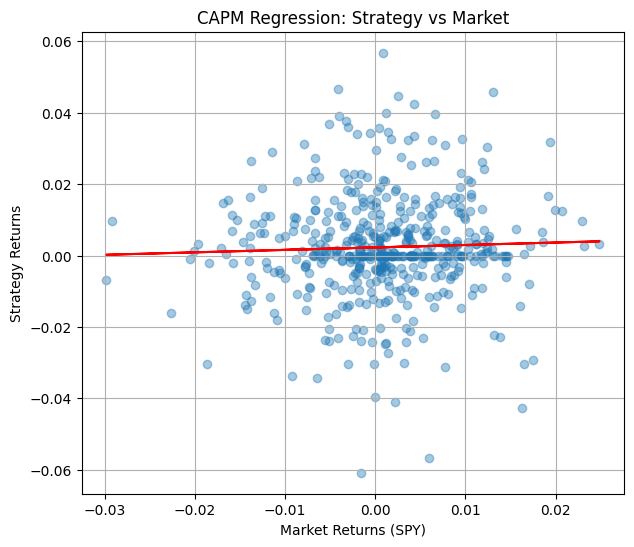

In [232]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))

plt.scatter(capm_df["market"], capm_df["strategy"], alpha=0.4)

x_vals = capm_df["market"]
y_vals = alpha + beta * x_vals

plt.plot(x_vals, y_vals, color="red")

plt.xlabel("Market Returns (SPY)")
plt.ylabel("Strategy Returns")

plt.title("CAPM Regression: Strategy vs Market")

plt.grid(True)
plt.show()

In [235]:
alpha = model.params["const"]

alpha_annual = alpha * 252

print("Daily Alpha:", alpha)
print("Annualized Alpha:", alpha_annual)

Daily Alpha: 0.0022669659826499928
Annualized Alpha: 0.5712754276277981


In [236]:
print("Daily Alpha:", f"{alpha:.6f}")
print("Annualized Alpha:", f"{alpha_annual:.2%}")

Daily Alpha: 0.002267
Annualized Alpha: 57.13%


In [237]:
performance_table["CAPM Alpha"] = alpha
performance_table["CAPM Alpha Annualized"] = alpha_annual

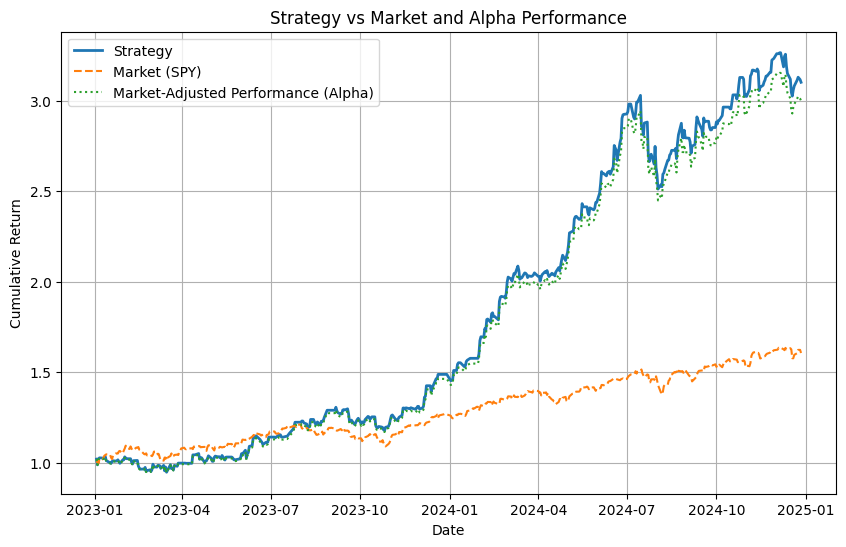

In [239]:
# cumulative strategy
strategy_cum = (1 + daily_strategy).cumprod()

# cumulative market
market_cum = (1 + market).cumprod()

# cumulative alpha (market-adjusted)
alpha_cumulative = (1 + excess_returns).cumprod()

plt.figure(figsize=(10,6))

plt.plot(strategy_cum, label="Strategy", linewidth=2)
plt.plot(market_cum, label="Market (SPY)", linestyle="--")
plt.plot(alpha_cumulative, label="Market-Adjusted Performance (Alpha)", linestyle=":")

plt.title("Strategy vs Market and Alpha Performance")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")

plt.legend()
plt.grid(True)

plt.show()